# Lab 2 — Analysis Notebook: Framingham Heart Study (Epidemiology)

**Dataset:** Framingham Heart Study teaching subset (~4,240 rows, one row per
participant, with a 10-year coronary heart disease (CHD) outcome).
See `data/SOURCE.md` for provenance — this is the widely-mirrored, de-identified
teaching subset used in many intro biostat/epi courses, **not** the
restricted-access official BioLINCC Framingham data.

**Question:** How does 10-year CHD risk vary by age and sex in this cohort,
and is systolic blood pressure associated with CHD risk within that pattern?


## 1. Load data from its original source

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

SOURCE_URL = (
    "https://raw.githubusercontent.com/GauravPadawe/Framingham-Heart-Study"
    "/master/framingham.csv"
)

fram = pd.read_csv(SOURCE_URL)
print(fram.shape)
fram.head()

(4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 2. Inspect and clean

The raw file uses `NA` for missing values and `male` (1/0) instead of a
readable sex label. We check missingness, drop rows missing any variable
used in this analysis, and recode `male` into a readable `sex` column.


In [2]:
missing_pct = fram.isna().mean().sort_values(ascending=False) * 100
missing_pct[missing_pct > 0]

glucose       9.150943
education     2.476415
BPMeds        1.250000
totChol       1.179245
cigsPerDay    0.683962
BMI           0.448113
heartRate     0.023585
dtype: float64

In [3]:
cols_needed = ["age", "male", "sysBP", "TenYearCHD"]
clean = fram.dropna(subset=cols_needed).copy()
clean["sex"] = clean["male"].map({1: "Male", 0: "Female"})

print(f"Rows before cleaning: {len(fram)}")
print(f"Rows after dropping missing age/sex/sysBP/outcome: {len(clean)}")

Rows before cleaning: 4240
Rows after dropping missing age/sex/sysBP/outcome: 4240


## 3. Transformation: age-decade CHD incidence by sex

This is the substantive transformation step: we bin continuous `age` into
decades, then compute the 10-year CHD *rate* (not just counts) within each
age-decade x sex group. Rates let us compare groups of very different sizes.


In [4]:
bins = [30, 40, 50, 60, 100]
labels = ["30s", "40s", "50s", "60+"]
clean["age_decade"] = pd.cut(clean["age"], bins=bins, labels=labels, right=False)

chd_by_group = (
    clean.groupby(["age_decade", "sex"], observed=True)["TenYearCHD"]
    .agg(n="count", chd_rate="mean")
    .reset_index()
)
chd_by_group["chd_rate_pct"] = (chd_by_group["chd_rate"] * 100).round(1)
chd_by_group

,age_decade,sex,n,chd_rate,chd_rate_pct
0,30s,Female,303,0.023102,2.3
1,30s,Male,253,0.063241,6.3
2,40s,Female,940,0.077660,7.8
3,40s,Male,721,0.130374,13.0
4,50s,Female,771,0.156939,15.7
5,50s,Male,562,0.252669,25.3
6,60+,Female,406,0.246305,24.6
7,60+,Male,284,0.320423,32.0


## 4. Visualization

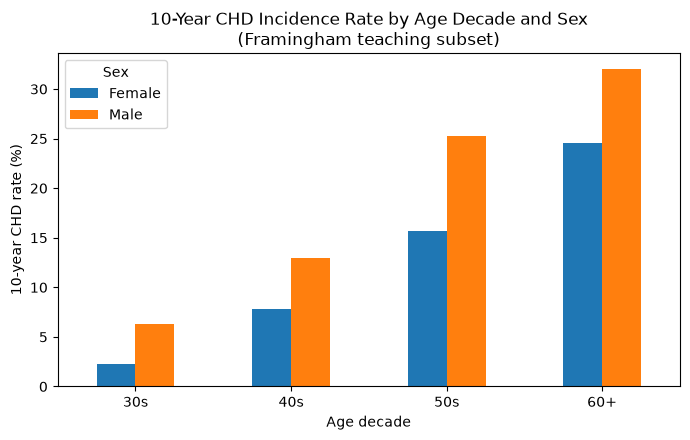

In [5]:
pivot = chd_by_group.pivot(index="age_decade", columns="sex", values="chd_rate_pct")

ax = pivot.plot(kind="bar", figsize=(7, 4.5), rot=0)
ax.set_title("10-Year CHD Incidence Rate by Age Decade and Sex\n(Framingham teaching subset)")
ax.set_xlabel("Age decade")
ax.set_ylabel("10-year CHD rate (%)")
ax.legend(title="Sex")
plt.tight_layout()
plt.savefig("../notebook/chd_by_age_sex.png", dpi=150)
plt.show()

## 5. A second look: blood pressure within the highest-risk group

Since CHD risk rises sharply with age, we zoom into participants aged 60+
and check whether systolic blood pressure (`sysBP`) differs between
those who did and did not develop CHD within 10 years.


In [6]:
older = clean[clean["age_decade"] == "60+"]
bp_summary = older.groupby("TenYearCHD")["sysBP"].agg(["count", "mean", "std"]).round(1)
bp_summary.index = bp_summary.index.map({0: "No CHD (10yr)", 1: "CHD (10yr)"})
bp_summary

,count,mean,std
TenYearCHD,,,
No CHD (10yr),499,143.7,24.9
CHD (10yr),191,152.9,29.8


## 6. Interpretation

10-year CHD incidence rises steadily with age in both sexes, from about
2–6% in participants' 30s to 25–32% in those 60 and older, and at every
age group men have a noticeably higher CHD rate than women (e.g. 25.3% vs.
15.7% in the 50s). Among participants aged 60+, those who went on to
develop CHD within 10 years had a higher mean systolic blood pressure
(152.9 mmHg) than those who did not (143.7 mmHg), consistent with
hypertension as a known CHD risk factor, though this cross-sectional
comparison of group means cannot establish causation on its own.
